# California Carbon Emissions Along Major Transportation Corridors

Analyze five major transportation hubs in California
- Los Angeles
- San Francisco
- San Diego
- Sacramento 
- Fresno

Transportation Pairs 
> Car Distances from Google Maps

> Air Distances from https://www.airmilescalculator.com/

1. Los Angeles - Sacramento
    - Car: 385 miles
    - Airplane: 373 miles
    - Rail: 247.25 + 26.67 + 143.02 = 416.94 miles
2. Los Angeles - San Francisco
    - Car: 382 miles
    - Airplane: 337 miles
    - Rail: 247.25 + 26.67 + 172.10 = 446.02 miles
3. Los Angeles - San Diego
    - Car: 120 miles
    - Airplane: 109 miles
    - Rail: 145.44 miles
4. Los Angeles - Fresno
    - Car: 219 miles
    - Airplane: 209 miles
    - Rail: 247.25 miles
5. Sacramento - San Francisco
    - Car: 87.5 miles
    - Airplane: 85.6 miles
    - Rail: 143.02 + 172.10 = 315.12 miles
6. Sacramento - San Diego
    - Car: 504 miles
    - Airplane: 480 miles
    - Rail: 416.94 + 145.44 = 562.38 miles
7. Sacramento - Fresno
    - Car: 169 miles
    - Airplane: No Nonstop flights
    - Rail: 26.67 + 143.02 = 169.69
8. San Francisco - San Diego
    - Car: 501 miles
    - Airplane: 447 miles
    - Rail: 446.02 + 145.44 = 591.46 miles
9. San Francisco - Fresno
    - Car: 186 miles
    - Airplane: 157.7 miles
    - Rail: 172.10 + 26.67 = 198.77 miles
10. San Diego - Fresno
    - Car: 339 miles
    - Airplane: 314 miles
    - Rail: 247.25 + 145.44 = 392.69 miles

Carbon Emissions data for High Speed Rail, Car, and Airliner:
[Source](https://railroads.dot.gov/sites/fra.dot.gov/files/fra_net/15009/Carbon%20Footprint%20of%20High-Speed%20Rail%20UIC%202011.pdf)

The study cites that in 2004, 20.4 million people took the LGV Mediterranee and an additional 4.46 million passengers traveled between Valence and Marseille. Each of the numbers assumes a trip of 600 km.

- S-E Atlantic (France): 10.4 g CO2 / pkm 
- LGV Mediterranée (France): 11.0 g CO2 / pkm 
- Taipei-Kaohsiung (Taiwan): 52.7 g CO2 / pkm 
- Beijing-Tianjin (China): 46.0 g CO2 / pkm 
- Car: 151.6 g CO2 / pkm (assumes 1.6 passengers)
- Airplane (European): 164.0 g CO2 / pkm

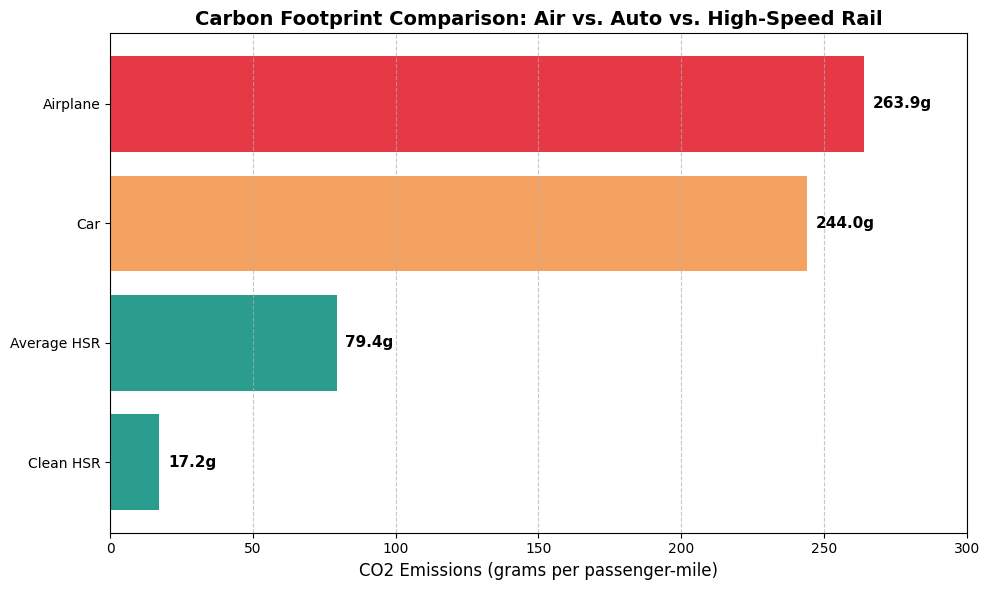

In [2]:
import matplotlib.pyplot as plt

# Conversion factor: 1 mile = 1.60934 kilometers
conversion_factor = 1.60934

# Data in grams of CO2 per passenger-kilometer (pkm)
airplane_pkm = 164.0
car_pkm = 151.6
avg_hsr_pkm = (52.7 + 46.0) / 2  # Average of Taiwan and China
clean_hsr_pkm = (10.4 + 11.0) / 2  # Average of the two French lines

# Convert to grams of CO2 per passenger-mile
emissions_per_mile = [
    airplane_pkm * conversion_factor,
    car_pkm * conversion_factor,
    avg_hsr_pkm * conversion_factor,
    clean_hsr_pkm * conversion_factor
]

# Labels for the chart
transport_modes = ["Airplane", "Car", "Average HSR", "Clean HSR"]

# Colors (Red for high emissions, Orange for medium, Green for low)
colors = ['#e63946', '#f4a261', '#2a9d8f', '#2a9d8f']

# Create the figure and horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(transport_modes, emissions_per_mile, color=colors)

# Add data labels to the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 3, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}g', 
             ha='left', va='center', fontsize=11, fontweight='bold')

# Formatting the chart
plt.xlabel('CO2 Emissions (grams per passenger-mile)', fontsize=12)
plt.title('Carbon Footprint Comparison: Air vs. Auto vs. High-Speed Rail', fontsize=14, fontweight='bold')
plt.xlim(0, 300) # Ensure there is enough space for the text labels
plt.gca().invert_yaxis() # Put the highest emissions at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the chart
plt.tight_layout()

In [3]:
import plotly.graph_objects as go

# 1. Constants and Conversion Factors
MILE_TO_KM = 1.60934
CAR_EMISSION_FACTOR = 151.6  # g CO2 / pkm
AIR_EMISSION_FACTOR = 164.0  # g CO2 / pkm

# 2. City Coordinates (Approximate Lat/Lon)
cities = {
    "Los Angeles": {"lat": 34.0522, "lon": -118.2437},
    "Sacramento": {"lat": 38.5816, "lon": -121.4944},
    "San Francisco": {"lat": 37.7749, "lon": -122.4194},
    "San Diego": {"lat": 32.7157, "lon": -117.1611},
    "Fresno": {"lat": 36.7378, "lon": -119.7871}
}

# 3. Route Data: (City 1, City 2, Car Miles, Air Miles)
routes = [
    ("Los Angeles", "Sacramento", 385, 373),
    ("Los Angeles", "San Francisco", 382, 337),
    ("Los Angeles", "San Diego", 120, 109),
    ("Los Angeles", "Fresno", 219, 209),
    ("Sacramento", "San Francisco", 87.5, 85.6),
    ("Sacramento", "San Diego", 504, 480),
    ("Sacramento", "Fresno", 169, None), # None for No Nonstop flights
    ("San Francisco", "San Diego", 501, 447),
    ("San Francisco", "Fresno", 186, 158),
    ("San Diego", "Fresno", 339, 314)
]

fig = go.Figure()

# --- BUILD CAR TRACES ---
car_lon, car_lat = list(), list()
car_text_lon, car_text_lat, car_text_labels = list(), list(), list()

for c1, c2, car_dist, _ in routes:
    if car_dist is not None:
        # Line coordinates
        car_lon.extend([cities[c1]["lon"], cities[c2]["lon"], None])
        car_lat.extend([cities[c1]["lat"], cities[c2]["lat"], None])
        
        # Calculate emissions
        emissions = int(car_dist * MILE_TO_KM * CAR_EMISSION_FACTOR/1000)
        
        # Label coordinates (Midpoint)
        car_text_lon.append((cities[c1]["lon"] + cities[c2]["lon"]) / 2)
        car_text_lat.append((cities[c1]["lat"] + cities[c2]["lat"]) / 2)
        car_text_labels.append(f"{emissions:,.0f}kg")

# Add Car Lines
fig.add_trace(go.Scattergeo(
    lon=car_lon, lat=car_lat,
    mode='lines',
    line=dict(width=2, color='#f4a261'),
    name='Car Routes'
))

# Add Car Text Labels
fig.add_trace(go.Scattergeo(
    lon=car_text_lon, lat=car_text_lat,
    mode='text',
    text=car_text_labels,
    textfont=dict(color='#d97706', size=11, weight='bold'),
    name='Car Emissions'
))

# --- BUILD AIRPLANE TRACES ---
air_lon, air_lat = list(), list()
air_text_lon, air_text_lat, air_text_labels = list(), list(), list()

for c1, c2, _, air_dist in routes:
    if air_dist is not None:
        # Line coordinates
        air_lon.extend([cities[c1]["lon"], cities[c2]["lon"], None])
        air_lat.extend([cities[c1]["lat"], cities[c2]["lat"], None])
        
        # Calculate emissions
        emissions = int(air_dist * MILE_TO_KM * AIR_EMISSION_FACTOR/1000)
        
        # Label coordinates (Midpoint)
        air_text_lon.append((cities[c1]["lon"] + cities[c2]["lon"]) / 2)
        air_text_lat.append((cities[c1]["lat"] + cities[c2]["lat"]) / 2)
        air_text_labels.append(f"{emissions:,.0f}kg")

# Add Airplane Lines
fig.add_trace(go.Scattergeo(
    lon=air_lon, lat=air_lat,
    mode='lines',
    line=dict(width=2, color='#e63946', dash='dot'),
    name='Airplane Routes',
    visible=False # Hidden by default
))

# Add Airplane Text Labels
fig.add_trace(go.Scattergeo(
    lon=air_text_lon, lat=air_text_lat,
    mode='text',
    text=air_text_labels,
    textfont=dict(color='#b91c1c', size=11, weight='bold'),
    name='Airplane Emissions',
    visible=False # Hidden by default
))

# --- BUILD CITY NODES TRACE ---
node_lon = [info["lon"] for info in cities.values()]
node_lat = [info["lat"] for info in cities.values()]
node_names = list(cities.keys())

fig.add_trace(go.Scattergeo(
    lon=node_lon, lat=node_lat,
    mode='markers+text',
    marker=dict(size=12, color='#264653', line=dict(width=2, color='white')),
    text=node_names,
    textposition="top center",
    textfont=dict(size=13, color='black', weight='bold'),
    name='Cities'
))

# --- CONFIGURE MAP AND INTERACTIVITY ---
# Create the toggle menu
updatemenus =[ 
    dict(
        type="buttons",
        direction="right",
        buttons=list([
            dict(
                label="View Car Emissions",
                method="update",
                args=[
                    {"visible": [True, True, False, False, True]}, # Traces 0,1,4 are visible
                    {"title": "California Corridors: Car Emissions per Passenger"}
                ]
            ),
            dict(
                label="View Airplane Emissions",
                method="update",
                args=[
                    {"visible": [False, False, True, True, True]}, # Traces 2,3,4 are visible
                    {"title": "California Corridors: Airplane Emissions per Passenger"}
                ]
            )
        ]),
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.5, 
        xanchor="center", 
        y=1.08, 
        yanchor="top"
    )
]

fig.update_geos(
    resolution=50,
    showcoastlines=True, coastlinecolor="RebeccaPurple",
    showland=True, landcolor="LightGreen",
    showocean=True, oceancolor="LightBlue",
    showlakes=True, lakecolor="Blue",
    showrivers=True, rivercolor="Blue",
    showcountries=True, countrycolor="Black",
    showsubunits=True, subunitcolor="Black"
)

fig.update_layout(
    title=dict(text="California Corridors: Car Emissions per Passenger", x=0.5, font=dict(size=18)),
    updatemenus=updatemenus,
    showlegend=False,
    geo=dict(
        scope='usa',
        projection_type='albers usa',#albers usa
        showland=True,
        # landcolor='rgb(243, 243, 243)',
        # subunitcolor="rgb(200, 200, 200)",
        # countrycolor="rgb(200, 200, 200)",
        # Zoom tightly on California
        center=dict(lat=36.0, lon=-119.5),
        lataxis_range=[32, 42],
        lonaxis_range=[-125, -114]
    ),
    height=800,
    margin={"r":0,"t":100,"l":0,"b":0}
)
fig.write_html("California_Corridors.html")
fig.show()

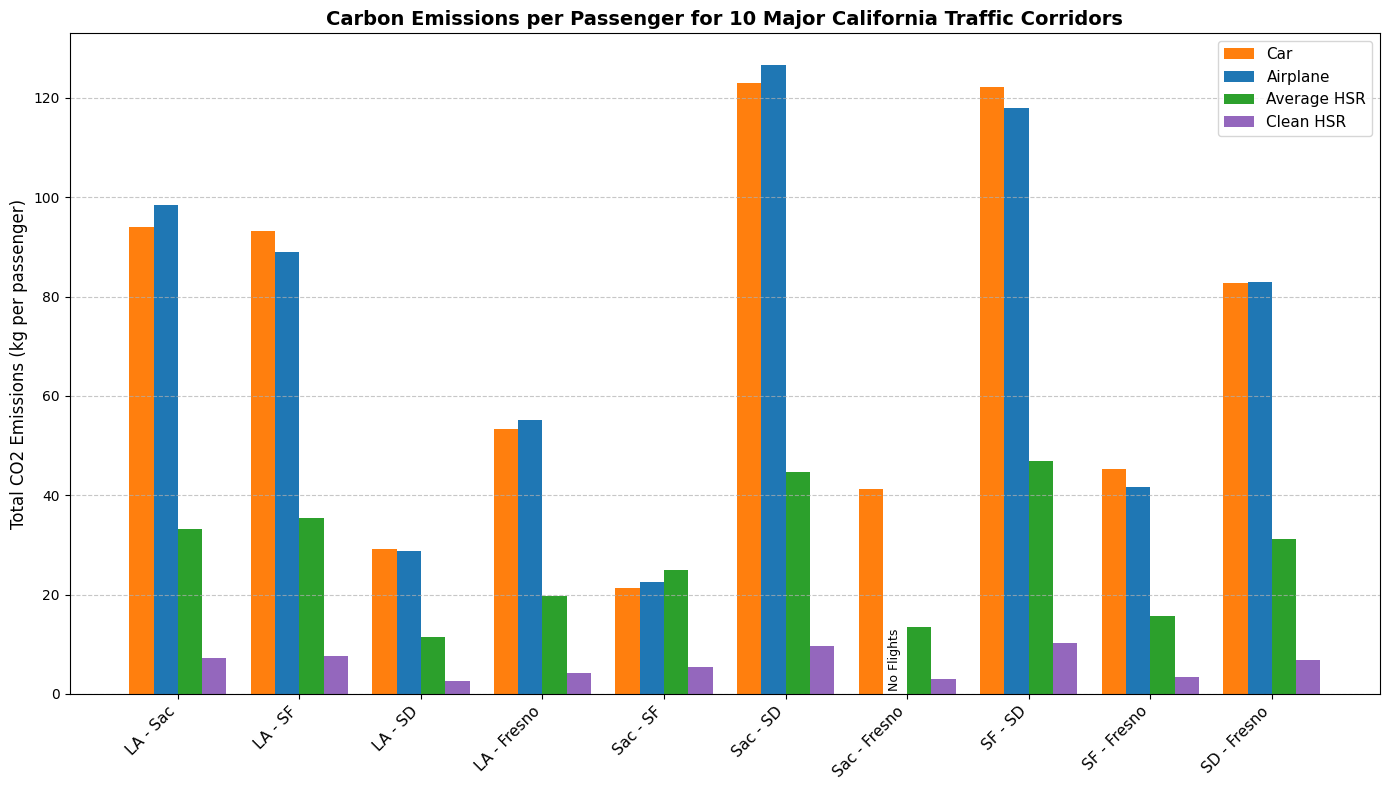

In [4]:
import numpy as np

# Data definitions
corridors = [
    "LA - Sac", "LA - SF", "LA - SD", "LA - Fresno", "Sac - SF", 
    "Sac - SD", "Sac - Fresno", "SF - SD", "SF - Fresno", "SD - Fresno"
]

car_miles = [385, 382, 120, 219, 87.5, 504, 169, 501, 186, 339]
air_miles = [373, 337, 109, 209, 85.6, 480, 0, 447, 157.7, 314] # 0 for "No Nonstop flights"
rail_miles = [416.94, 446.02, 145.44, 247.25, 315.12, 562.38, 169.69, 591.46, 198.77, 392.69]

# Conversion factor: 1 mile = 1.60934 kilometers
conversion_factor = 1.60934

# Data in grams of CO2 per passenger-kilometer (pkm)
airplane_pkm = 164.0
car_pkm = 151.6
avg_hsr_pkm = (52.7 + 46.0) / 2  # Average of Taiwan and China
clean_hsr_pkm = (10.4 + 11.0) / 2  # Average of the two French lines

# Calculate emissions in kg of CO2 per passenger (divide by 1000)
car_emissions = [m * conversion_factor * car_pkm / 1000 for m in car_miles]
air_emissions = [m * conversion_factor * airplane_pkm / 1000 if m > 0 else 0 for m in air_miles]
avg_hsr_emissions = [m * conversion_factor * avg_hsr_pkm / 1000 for m in rail_miles]
clean_hsr_emissions = [m * conversion_factor * clean_hsr_pkm / 1000 for m in rail_miles]

# Set up the plot dimensions
x = np.arange(len(corridors))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 8))

# Grouped bars for each travel mode
rects1 = ax.bar(x - 1.5*width, car_emissions, width, label='Car', color='#ff7f0e')
rects2 = ax.bar(x - 0.5*width, air_emissions, width, label='Airplane', color='#1f77b4')
rects3 = ax.bar(x + 0.5*width, avg_hsr_emissions, width, label='Average HSR', color='#2ca02c')
rects4 = ax.bar(x + 1.5*width, clean_hsr_emissions, width, label='Clean HSR', color='#9467bd')

# Add labels, title, and formatting
ax.set_ylabel('Total CO2 Emissions (kg per passenger)', fontsize=12)
ax.set_title('Carbon Emissions per Passenger for 10 Major California Traffic Corridors', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(corridors, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels for zero values
for i, val in enumerate(air_miles):
    if val == 0:
        ax.text(x[i]-0.05, 0.5, 'No Flights', ha='right', va='bottom', rotation=90, fontsize=9, color='black')

# Adjust layout to prevent label clipping
plt.tight_layout()

# Save figure
plt.savefig('california_corridors_emissions.png', dpi=300)

In [10]:
import pandas as pd
df = pd.DataFrame(data=[car_emissions,air_emissions,avg_hsr_emissions,clean_hsr_emissions], columns=corridors)
df = df.transpose()
df.head()

,0,1,2,3
LA - Sac,93.930738,98.446546,33.113762,7.179681
LA - SF,93.198811,88.945003,35.423323,7.680437
LA - SD,29.277113,28.768562,11.550980,2.504468
LA - Fresno,53.430732,55.161738,19.636825,4.257630
Sac - SF,21.347895,22.592559,25.027123,5.426347


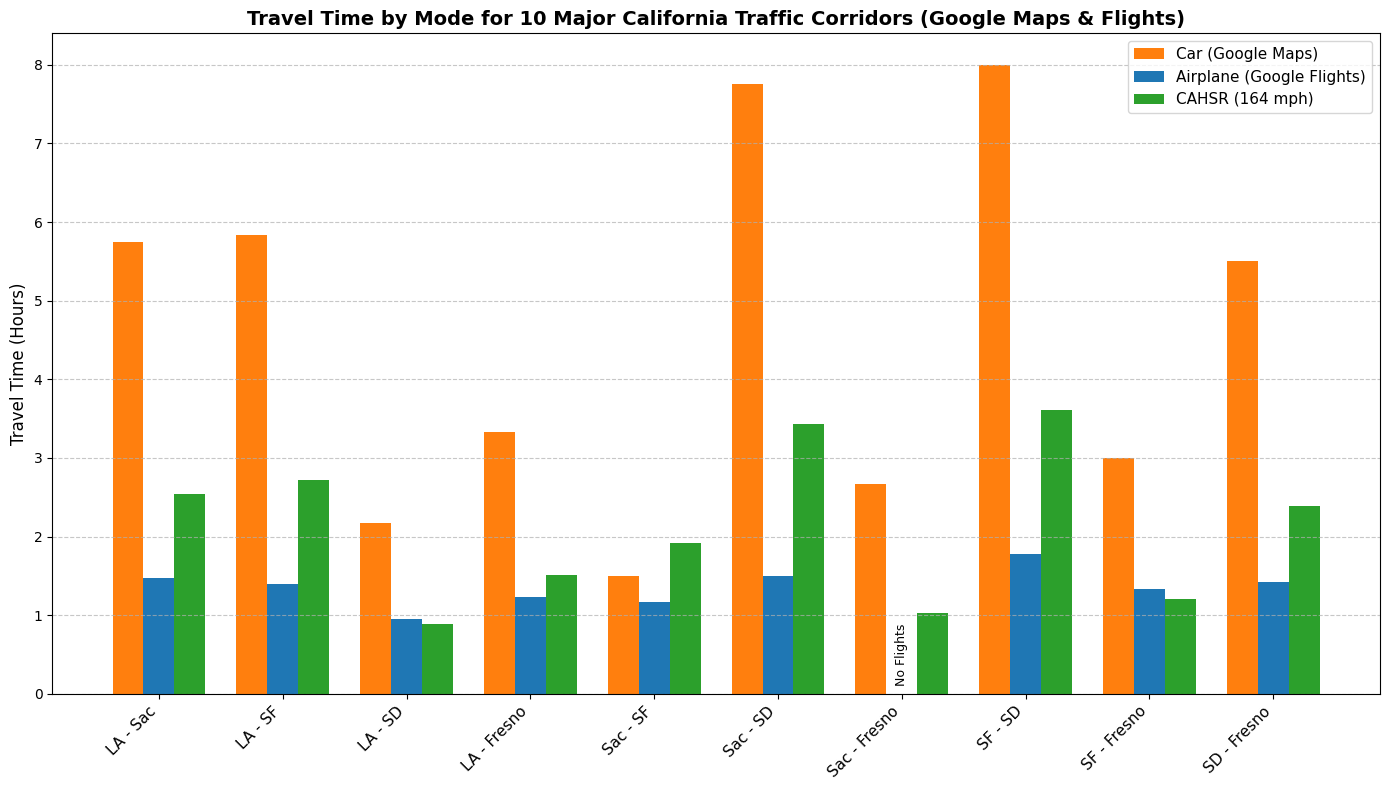

In [6]:
# Data definitions
corridors = [
    "LA - Sac", "LA - SF", "LA - SD", "LA - Fresno", "Sac - SF", 
    "Sac - SD", "Sac - Fresno", "SF - SD", "SF - Fresno", "SD - Fresno"
]

# Distances for HSR calculation
rail_miles = [416.94, 446.02, 145.44, 247.25, 315.12, 562.38, 169.69, 591.46, 198.77, 392.69]
hsr_speed = 164  # mph

# Calculate HSR travel times
hsr_times = [m / hsr_speed for m in rail_miles]

# Google Maps typical driving times (in hours)
car_times = [
    5.75,   # LA - Sac (~5h 45m)
    5.83,   # LA - SF (~5h 50m)
    2.17,   # LA - SD (~2h 10m)
    3.33,   # LA - Fresno (~3h 20m)
    1.50,   # Sac - SF (~1h 30m)
    7.75,   # Sac - SD (~7h 45m)
    2.67,   # Sac - Fresno (~2h 40m)
    8.00,   # SF - SD (~8h 0m)
    3.00,   # SF - Fresno (~3h 0m)
    5.50    # SD - Fresno (~5h 30m)
]

# Google Flights average non-stop flight times (in hours)
air_times = [
    1.47,   # LA - Sac (1h 28m)
    1.40,   # LA - SF (1h 24m)
    0.95,   # LA - SD (57m)
    1.23,   # LA - Fresno (1h 14m)
    1.17,   # Sac - SF (1h 10m)
    1.50,   # Sac - SD (1h 30m)
    0.00,   # Sac - Fresno (No nonstop flights)
    1.78,   # SF - SD (1h 47m)
    1.33,   # SF - Fresno (1h 20m)
    1.42    # SD - Fresno (1h 25m)
]

x = np.arange(len(corridors))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

# Grouped bars for travel time
rects1 = ax.bar(x - width, car_times, width, label='Car (Google Maps)', color='#ff7f0e')
rects2 = ax.bar(x, air_times, width, label='Airplane (Google Flights)', color='#1f77b4')
rects3 = ax.bar(x + width, hsr_times, width, label='CAHSR (164 mph)', color='#2ca02c')

# Labels and formatting
ax.set_ylabel('Travel Time (Hours)', fontsize=12)
ax.set_title('Travel Time by Mode for 10 Major California Traffic Corridors (Google Maps & Flights)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(corridors, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels for zero values
for i, val in enumerate(air_times):
    if val == 0:
        ax.text(x[i], 0.1, 'No Flights', ha='center', va='bottom', rotation=90, fontsize=9, color='black')

plt.tight_layout()
plt.savefig('california_corridors_travel_time_updated.png', dpi=300)

In [7]:
df = pd.DataFrame(data=[hsr_times, car_times, air_times], columns=corridors)
df.head()
df.to_csv("California_Corridors.csv", index=False)